# RandomForestRegression

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [9]:
df = pd.read_csv('/workspaces/Supervised-Machine-Learning/Datasets/50_Startups.csv')
display(df.head())
print('Shape:', df.shape)
print('\nMissing values:')
print(df.isnull().sum())

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


Shape: (50, 5)

Missing values:
R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64


In [10]:
X = df.drop('Profit', axis=1)
y = df['Profit']

categorical_features = ['State']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
 )

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (40, 4)
Test shape: (10, 4)


In [11]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        max_depth=None
    ))
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

In [12]:
gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=2,
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train)
gb_pred = gb_pipeline.predict(X_test)

In [13]:
def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

rf_scores = regression_metrics(y_test, rf_pred)
gb_scores = regression_metrics(y_test, gb_pred)

comparison = pd.DataFrame([
    {'Model': 'RandomForestRegressor (Bagging)', **rf_scores},
    {'Model': 'GradientBoostingRegressor (Boosting)', **gb_scores}
]).sort_values(by='R2', ascending=False).reset_index(drop=True)

display(comparison)

,Model,MAE,RMSE,R2
0,RandomForestRegressor (Bagging),6010.927577,8380.106399,0.913279
1,GradientBoostingRegressor (Boosting),7805.182829,8453.080114,0.911762


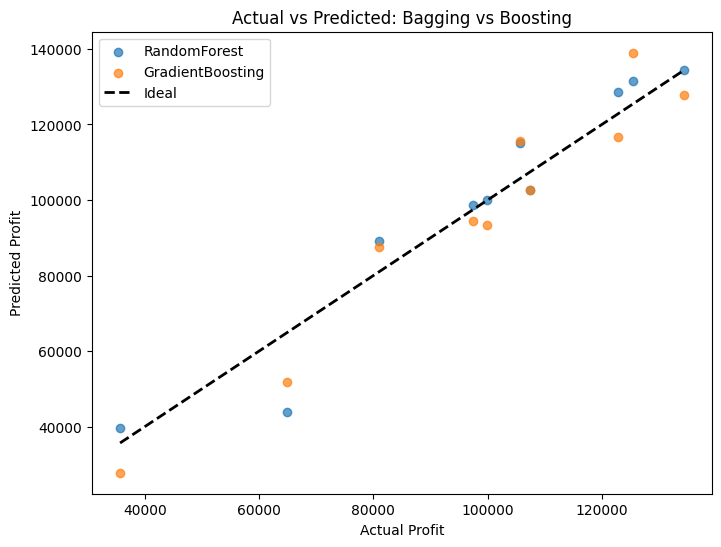

In [14]:
plot_df = pd.DataFrame({
    'Actual': y_test.values,
    'RandomForest': rf_pred,
    'GradientBoosting': gb_pred
})

plt.figure(figsize=(8, 6))
plt.scatter(plot_df['Actual'], plot_df['RandomForest'], alpha=0.7, label='RandomForest')
plt.scatter(plot_df['Actual'], plot_df['GradientBoosting'], alpha=0.7, label='GradientBoosting')
plt.plot([plot_df['Actual'].min(), plot_df['Actual'].max()],
         [plot_df['Actual'].min(), plot_df['Actual'].max()],
         'k--', linewidth=2, label='Ideal')
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.title('Actual vs Predicted: Bagging vs Boosting')
plt.legend()
plt.show()